In [82]:
# Importing the basic libraries

import cv2
import glob
import numpy as np
import pytesseract
from pprint import pprint
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [14,8]

import warnings 
warnings.filterwarnings('ignore')

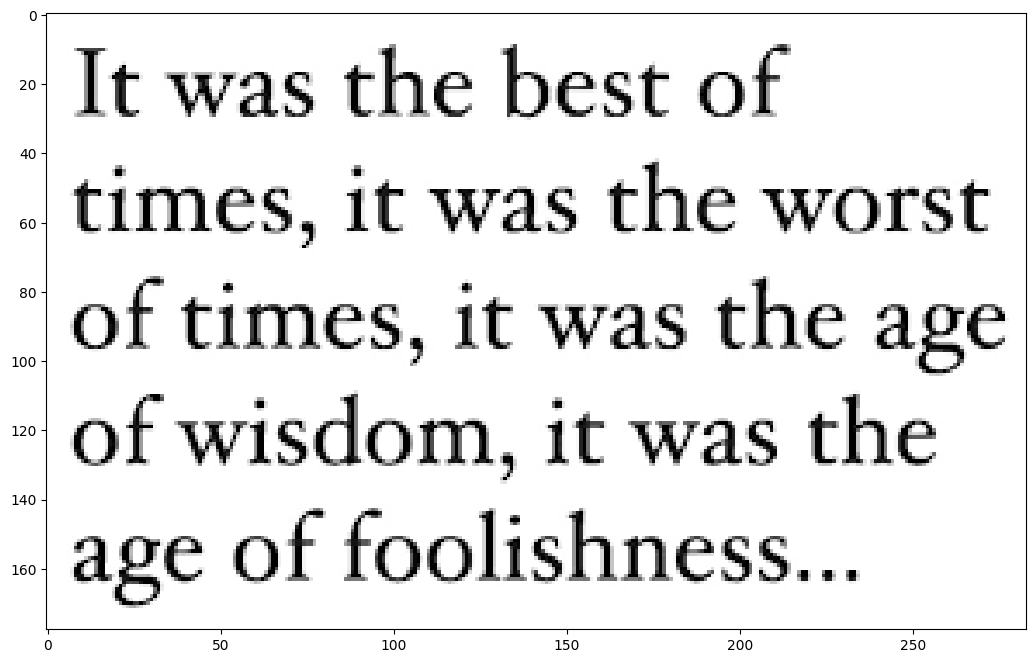

In [83]:
# Reading the image file
img = cv2.imread('Images/test1.png')
# Plotting the image
def plot_image(img, cmap=None):
    plt.imshow(img, cmap=cmap)
    
plot_image(img)
plt.show()

Image Processing


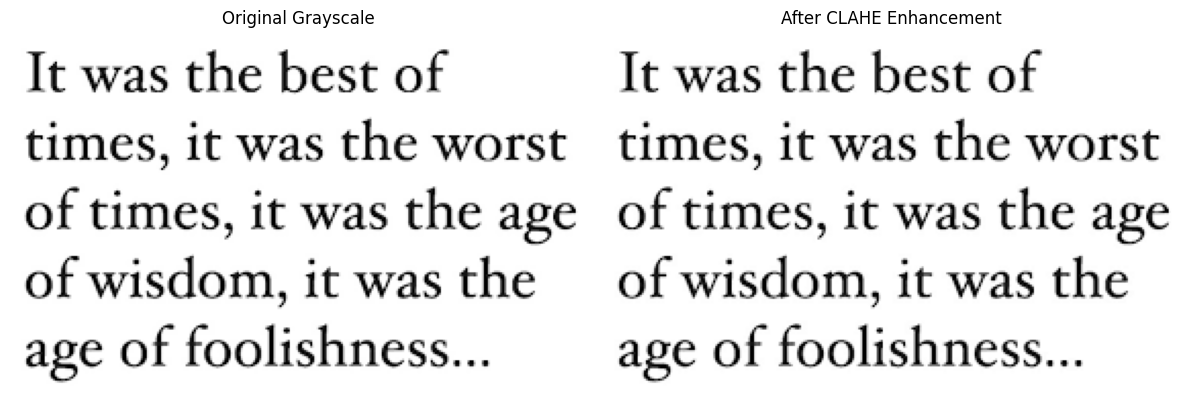

In [84]:
# Converting the image to grayscale
def get_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray_img = get_grayscale(img)

# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization):
enhanced_img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(gray_img)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(enhanced_img, cmap='gray')
axes[1].set_title('After CLAHE Enhancement')
axes[1].axis('off')

plt.tight_layout()
plt.show()

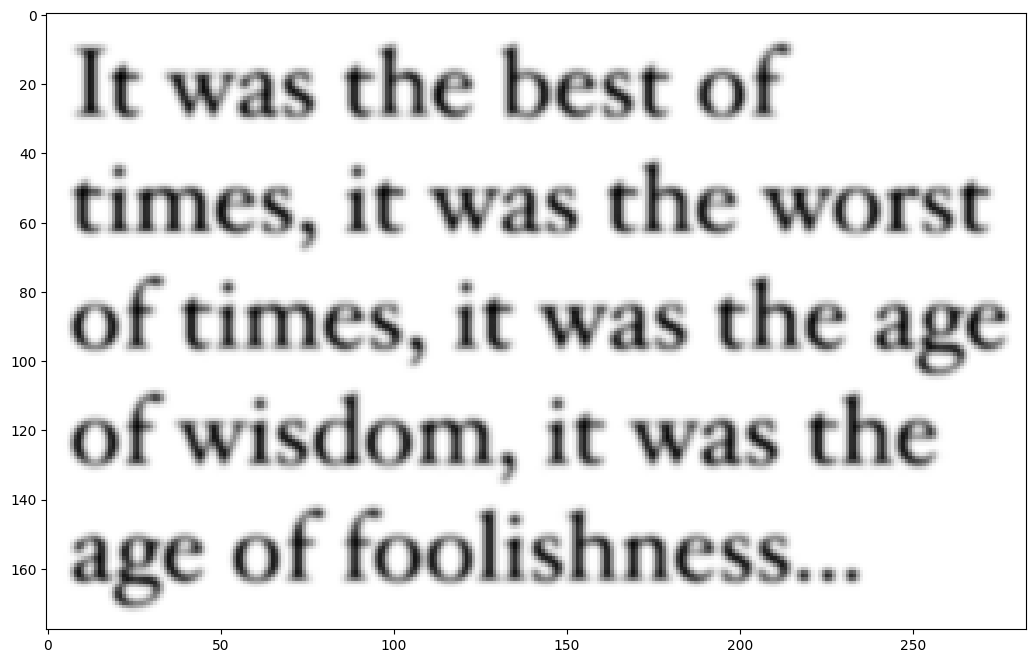

In [85]:
# Applying Gaussian Blur

def remove_noise(image):
    return cv2.GaussianBlur(enhanced_img,(5,5),1)

blur_img = remove_noise(enhanced_img)

plot_image(blur_img, cmap='gray')
plt.show()  

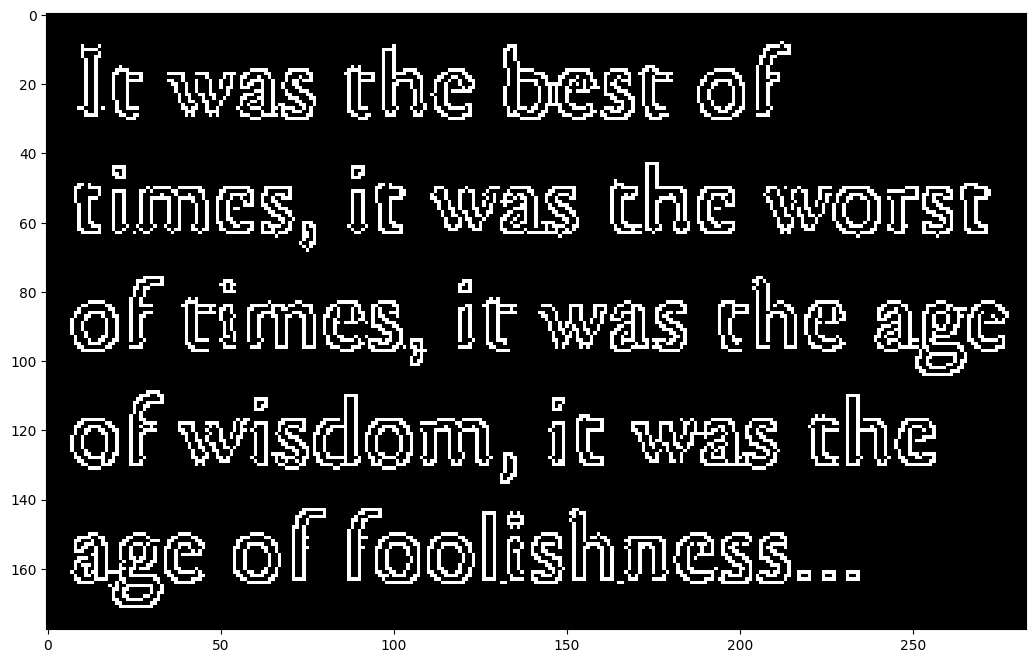

In [86]:
# Applying Canny Edge Detection

def Edge_detection(image):
    return cv2.Canny(blur_img,100,200)

edged_img = Edge_detection(blur_img)

plt.imshow(edged_img, cmap='gray')
plt.show()

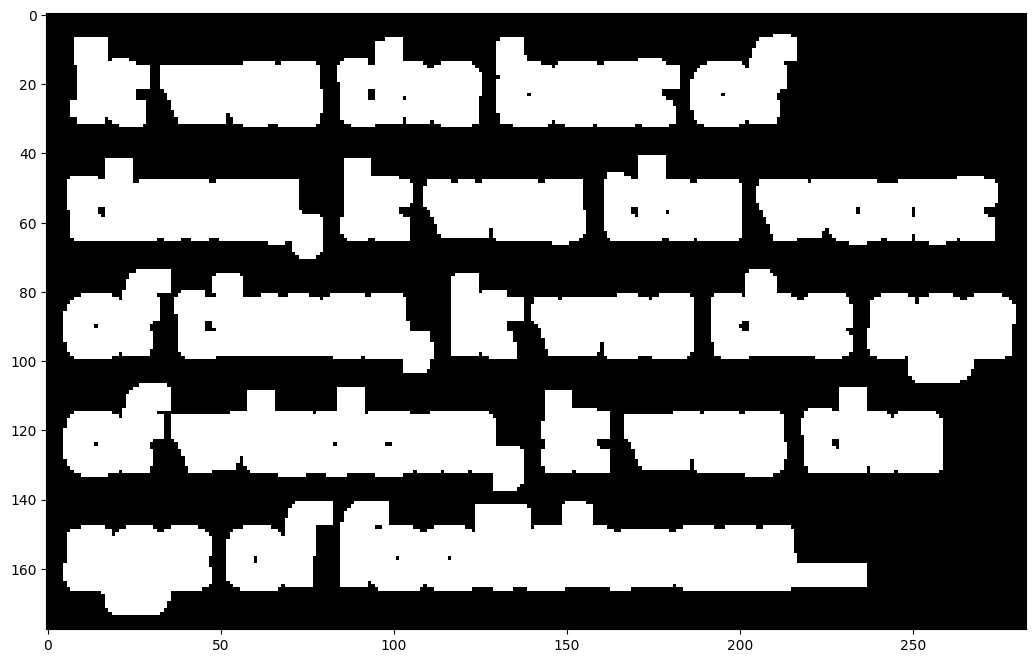

In [87]:
# Applying Dilation

def dilate(image):
    kernel = np.ones((3,3),np.uint8)
    return cv2.dilate(image, kernel, iterations = 2)

dilated_image = dilate(edged_img)

plt.imshow(dilated_image, cmap='gray')
plt.show()

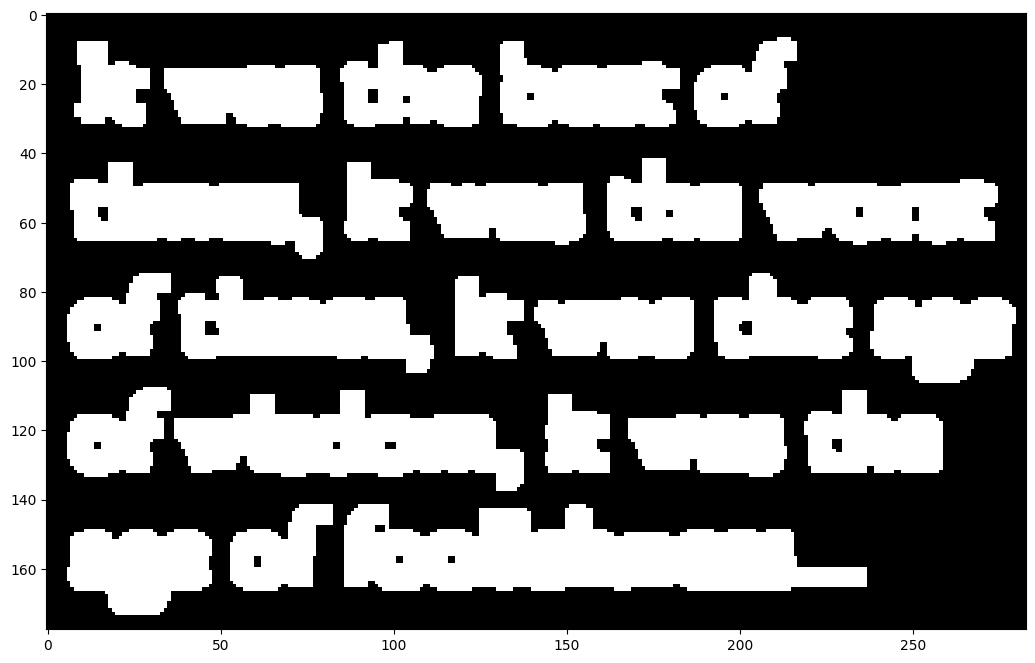

In [88]:
# Applying Erosion

def erode(image):
    kernel = np.ones((2,2),np.uint8)
    return cv2.erode(image, kernel, iterations = 1)

eroded_image = erode(dilated_image)

plt.imshow(eroded_image, cmap='gray')
plt.show()


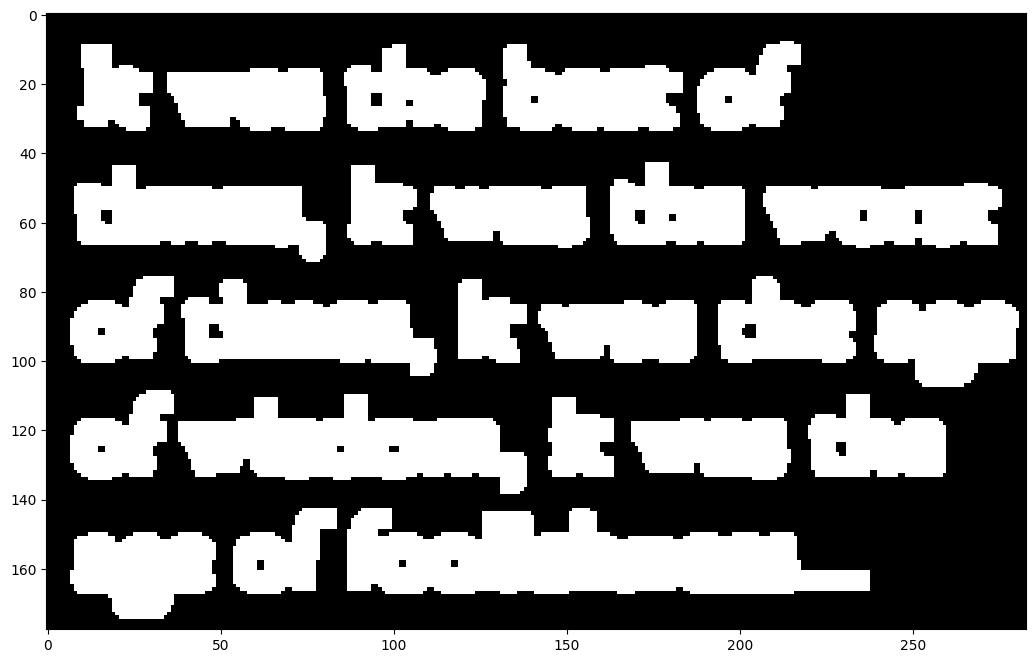

In [89]:
# opening - erosion followed by dilation

def opening(image):
    kernel = np.ones((2,2),np.uint8)
    return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

opening_image = opening(eroded_image)

plt.imshow(opening_image, cmap='gray')
plt.show()

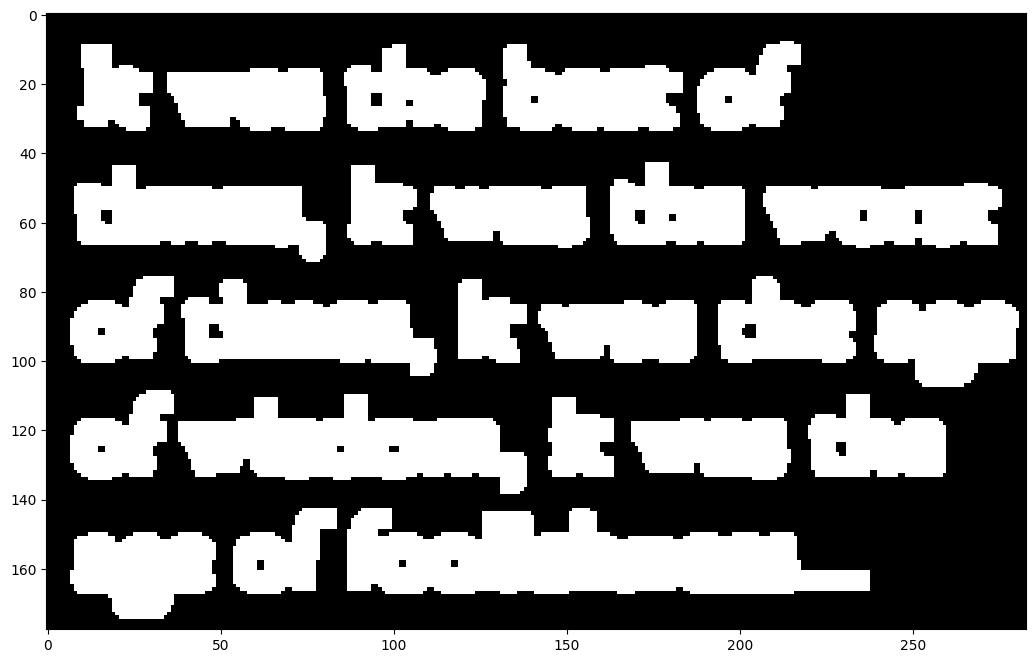

In [90]:
# opening - erosion followed by dilation

def opening(image):
    kernel = np.ones((2,2),np.uint8)
    return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

opening_image = opening(eroded_image)

plt.imshow(opening_image, cmap='gray')
plt.show()

In [91]:
# Creating Wrapping Funcctions

def order_points(pts):
    # initialzie a list of coordinates that will be ordered
    # such that the first entry in the list is the top-left,
    # the second entry is the top-right, the third is the
    # bottom-right, and the fourth is the bottom-left
    rect = np.zeros((4, 2), dtype = "float32")

    # the top-left point will have the smallest sum, whereas
    # the bottom-right point will have the largest sum
    s = pts.sum(axis = 1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    # now, compute the difference between the points, the
    # top-right point will have the smallest difference,
    # whereas the bottom-left will have the largest difference
    diff = np.diff(pts, axis = 1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    # return the ordered coordinates
    return rect

def four_point_transform(image, pts):
    # obtain a consistent order of the points and unpack them
    # individually
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # compute the width of the new image, which will be the
    # maximum distance between bottom-right and bottom-left
    # x-coordiates or the top-right and top-left x-coordinates
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # compute the height of the new image, which will be the
    # maximum distance between the top-right and bottom-right
    # y-coordinates or the top-left and bottom-left y-coordinates
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    # now that we have the dimensions of the new image, construct
    # the set of destination points to obtain a "birds eye view",
    # (i.e. top-down view) of the image, again specifying points
    # in the top-left, top-right, bottom-right, and bottom-left
    # order
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype = "float32")

    # compute the perspective transform matrix and then apply it
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    # return the warped image
    return warped

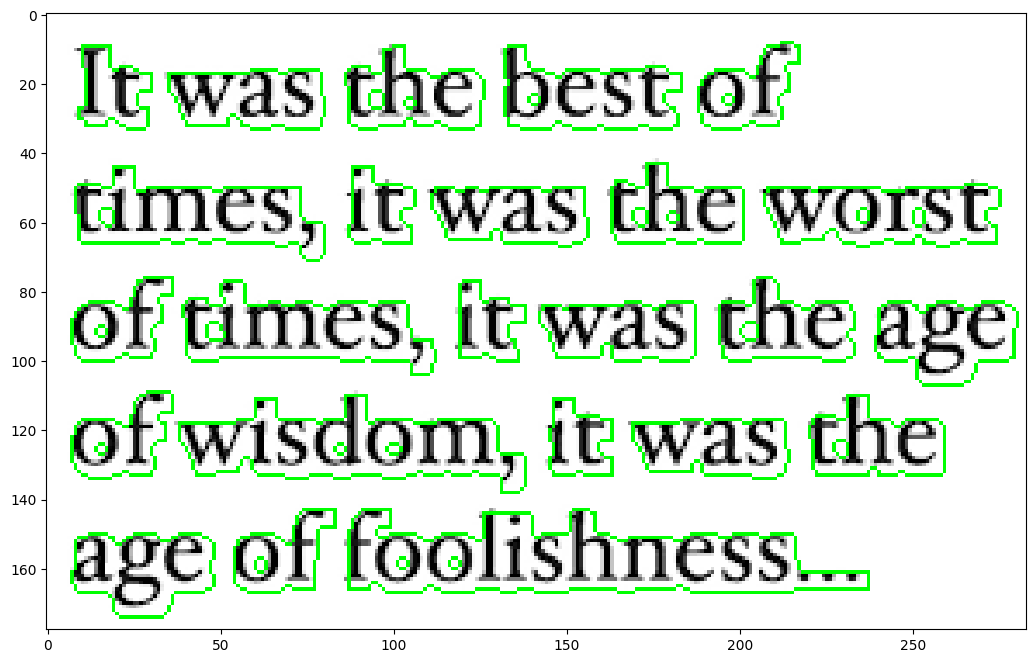

In [92]:
# Detecting Contours

contours, _ = cv2.findContours(opening_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

outline_contours = img.copy()
cv2.drawContours(outline_contours, contours, contourIdx=-1,color=(0, 255, 0))
    
plt.imshow(outline_contours, cmap='gray')
plt.show()

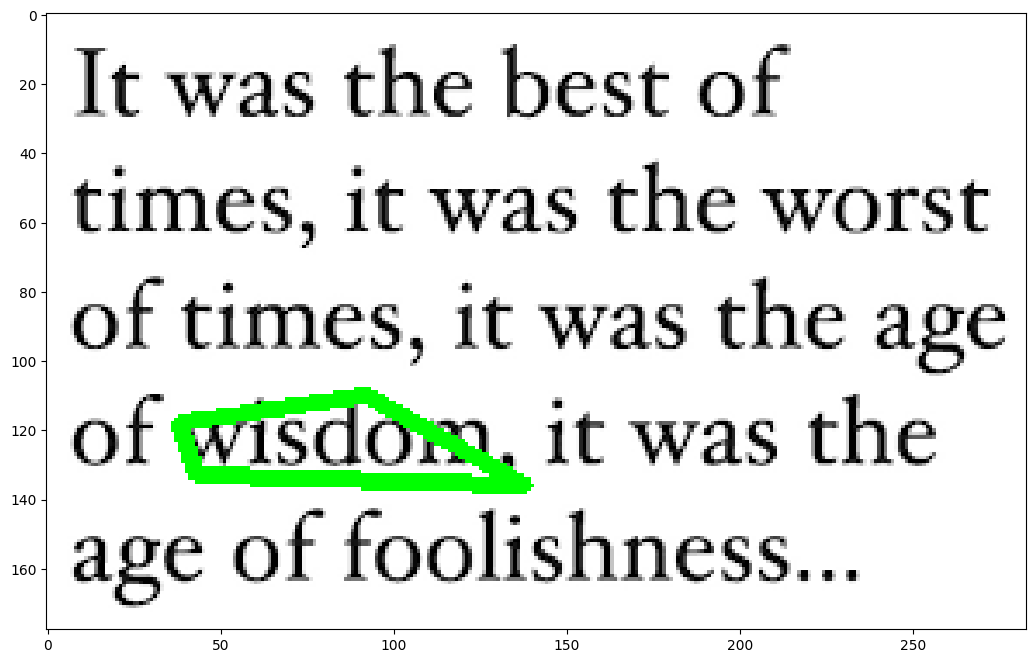

In [93]:
# Applying Ouline Contour

# go through each contour
for contour in contours:
    # we approximate the contour
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.05 * peri, True)
    # if we found a countour with 4 points we break the for loop
    # (we can assume that we have found our document)
    if len(approx) == 4:
        doc_cnts = approx
        break
        
# We draw the contours on the original image not the modified one
all_contours = img.copy()
cv2.drawContours(all_contours, [doc_cnts], -1, (0, 255, 0), 3)

plt.imshow(all_contours)
plt.show()

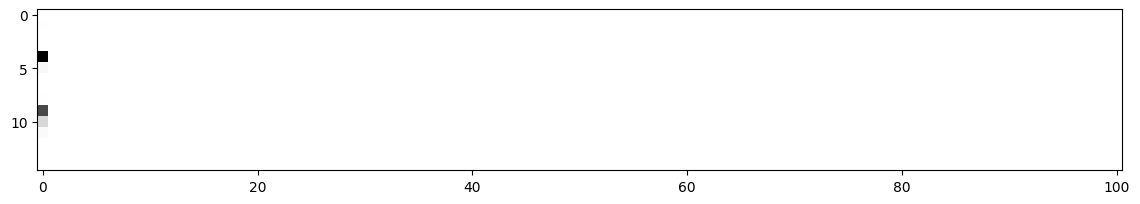

In [94]:
# Cropping Image

# cv2.imshow("Contours of the document", orig_image)
# apply warp perspective to get the top-down view
warped = four_point_transform(img, doc_cnts.reshape(4, 2))
# convert the warped image to grayscale
warped = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
# cv2.imshow("Scanned", cv2.resize(warped, (600, 800)))

plt.imshow(warped, cmap='gray')
plt.show()

In [95]:
# Extracting text from cropped image

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
out_below = pytesseract.image_to_string(warped)
print(out_below)